# MSFR POD/SVD Analysis

Proper Orthogonal Decomposition of each MSFR training matrix.
Plots variance captured per mode, reports ranks needed for 75/90/95% variance,
and finds the Gavish-Donoho optimal hard threshold rank.

**Dataset:** 11 training files, each of shape `[Ntrain, 19400]` (19,400 spatial nodes).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


In [2]:
DATA_DIR = Path("../data/msfr/train")
TRAIN_FILES = [f"X{i}train.npz" for i in range(1, 12)]  # X1train–X11train

# Switch: "variance"       → right plot shows cumulative explained variance (0–1)
#         "relative_error" → right plot shows Frobenius reconstruction error sqrt(1 - cum_var)
METRIC = "relative_error"

## Helper functions

### Gavish-Donoho optimal hard threshold

Given a noisy matrix $Y = X + \sigma Z$ (signal $X$, i.i.d. Gaussian noise $Z$, unknown $\sigma$),
the Gavish-Donoho threshold minimises the Frobenius-norm reconstruction error
(Gavish & Donoho 2014, *IEEE TIT* 60(8)):

$$\tau^* = \omega(\beta) \cdot \mathrm{median}(\sigma_i(Y))$$

where $\beta = m/n$ ($m \le n$) is the matrix aspect ratio and

$$\omega(\beta) \approx 0.56\beta^3 - 0.95\beta^2 + 1.82\beta + 1.43 \qquad (\text{max error} \le 0.02)$$

is a polynomial fit to the ratio $\lambda^*(\beta)/\mu_\beta$, where $\lambda^*(\beta)$ is the
optimal threshold coefficient from the Marchenko-Pastur law and $\mu_\beta$ is the median of
the Marchenko-Pastur distribution at aspect ratio $\beta$.

Sanity check: $\omega(1) = 0.56 - 0.95 + 1.82 + 1.43 = 2.86$, matching the paper's
square-matrix value of $2.858$.

In [3]:
def gavish_donoho_threshold(singular_values, m, n):
    """
    Gavish & Donoho (2014) optimal hard threshold for unknown noise.

    tau = omega(beta) * median(singular_values)
    omega(beta) = 0.56*beta^3 - 0.95*beta^2 + 1.82*beta + 1.43
    beta = min(m, n) / max(m, n)

    Returns (threshold, n_modes_above_threshold).
    """
    if m > n:
        m, n = n, m  # enforce m <= n so beta in (0, 1]
    beta = m / n
    omega = 0.56 * beta**3 - 0.95 * beta**2 + 1.82 * beta + 1.43
    threshold = omega * np.median(singular_values)
    n_modes = int(np.sum(singular_values > threshold))
    return threshold, n_modes


def rank_for_variance(cum_var, target):
    """Return the number of modes needed to reach `target` cumulative variance fraction."""
    idx = np.searchsorted(cum_var, target)  # first index where cum_var >= target
    return int(idx) + 1  # convert to 1-indexed rank


def rank_for_error(rel_error_arr, target):
    """Return modes needed for relative Frobenius error to drop to <= target."""
    idx = np.searchsorted(-rel_error_arr, -target)  # flip sign: array becomes increasing
    return int(idx) + 1

## Analysis loop

For each training matrix:
1. Load and mean-centre the data
2. Compute economy SVD → singular values
3. Plot scree (log-scale) and cumulative variance
4. Report Gavish-Donoho rank and ranks for 75 / 90 / 95 % variance

Processing X1train.npz...
  Running SVD on shape (2000, 19400)...


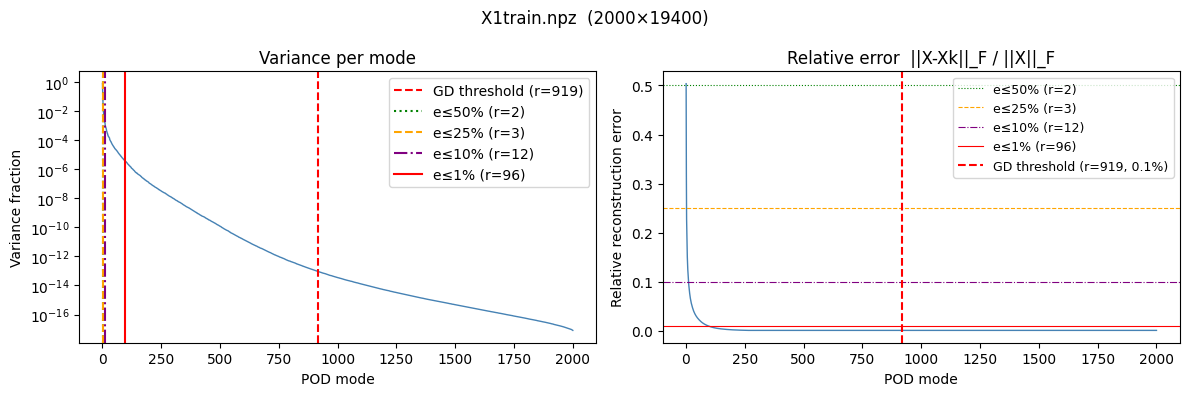

  re50=2,re25=3,re10=12,re1=96, GD rank=919 (0.1%)
Processing X2train.npz...
  Running SVD on shape (2000, 19400)...


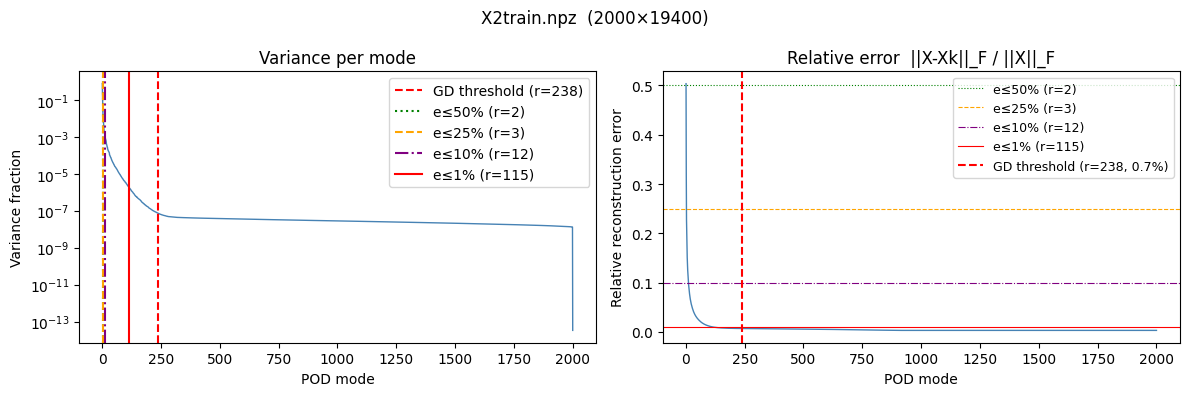

  re50=2,re25=3,re10=12,re1=115, GD rank=238 (0.7%)
Processing X3train.npz...
  Running SVD on shape (2000, 19400)...


/tmp/ipykernel_533155/639309750.py:13: RuntimeWarning: invalid value encountered in sqrt
  rel_error = np.sqrt(1 - cum_var)


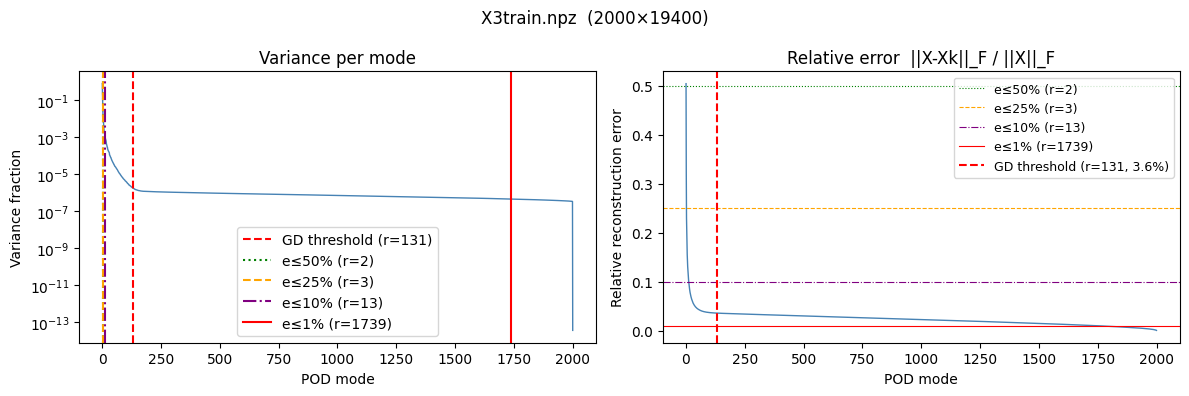

  re50=2,re25=3,re10=13,re1=1739, GD rank=131 (3.6%)
Processing X4train.npz...
  Running SVD on shape (500, 19400)...


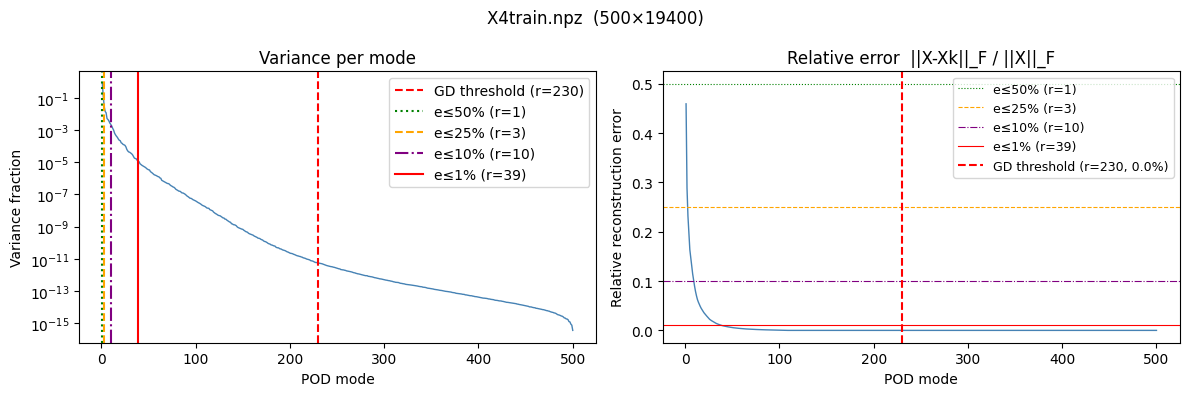

  re50=1,re25=3,re10=10,re1=39, GD rank=230 (0.0%)
Processing X5train.npz...
  Running SVD on shape (500, 19400)...


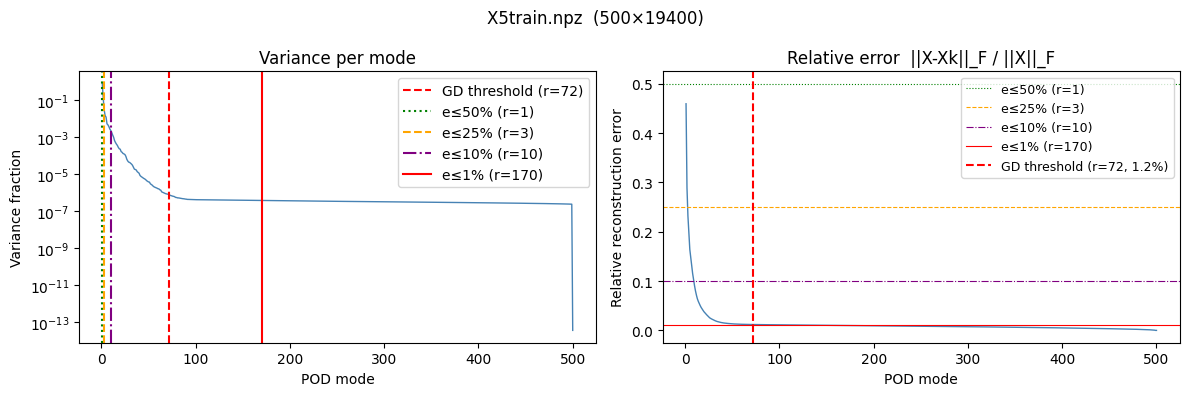

  re50=1,re25=3,re10=10,re1=170, GD rank=72 (1.2%)
Processing X6train.npz...
  Running SVD on shape (1500, 19400)...


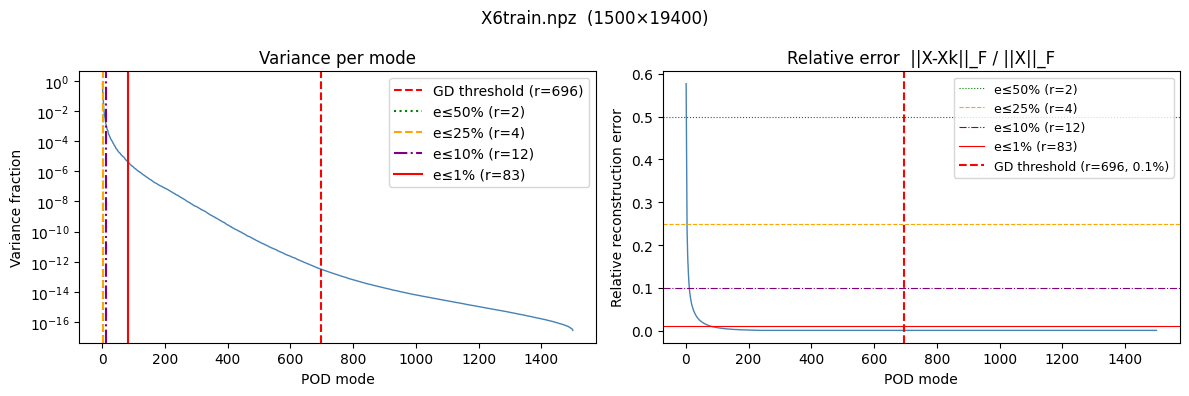

  re50=2,re25=4,re10=12,re1=83, GD rank=696 (0.1%)
Processing X7train.npz...
  Running SVD on shape (1500, 19400)...


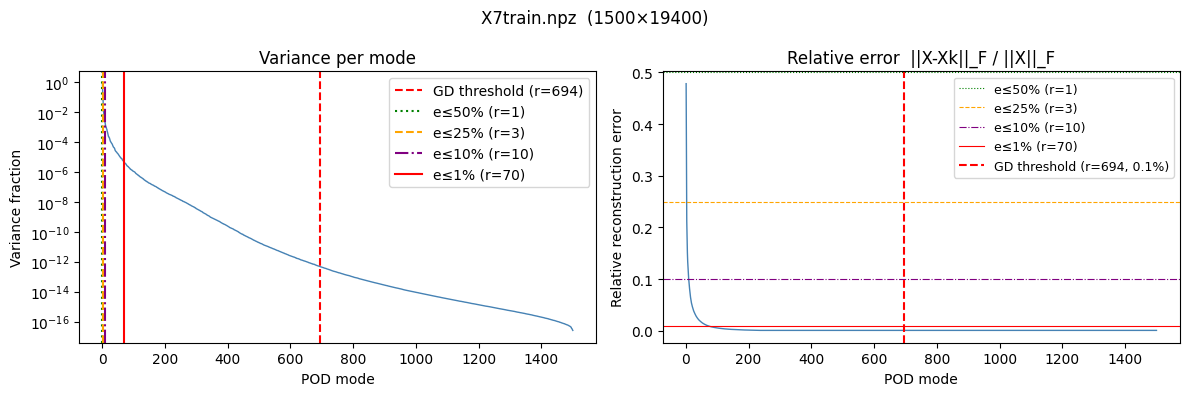

  re50=1,re25=3,re10=10,re1=70, GD rank=694 (0.1%)
Processing X8train.npz...
  Running SVD on shape (1500, 19400)...


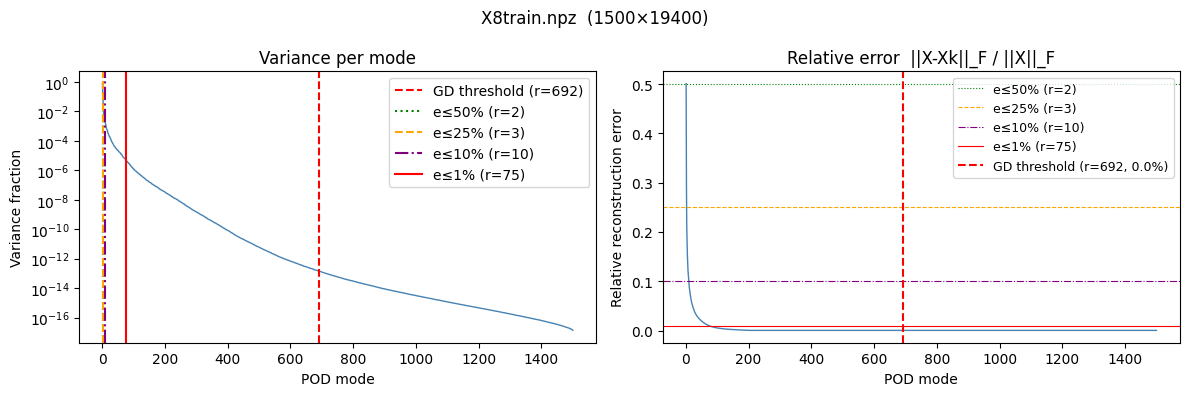

  re50=2,re25=3,re10=10,re1=75, GD rank=692 (0.0%)
Processing X9train.npz...
  Running SVD on shape (500, 19400)...


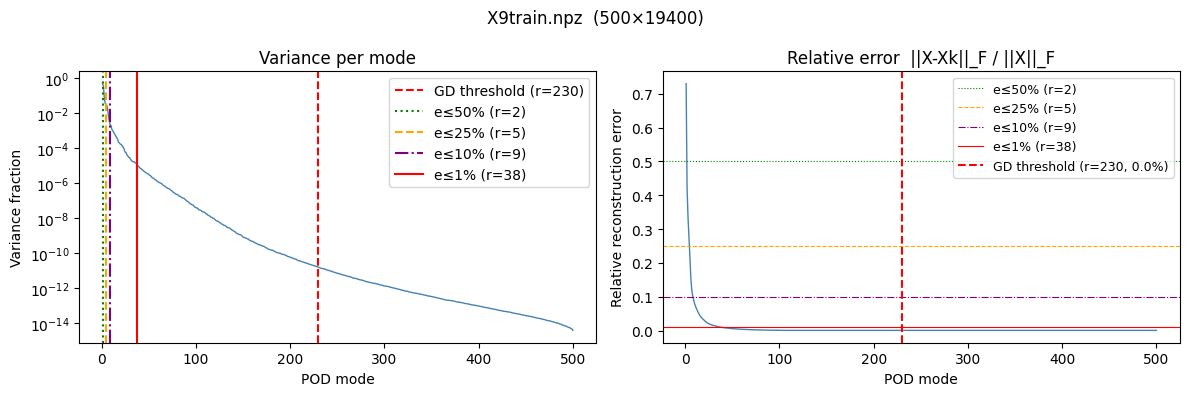

  re50=2,re25=5,re10=9,re1=38, GD rank=230 (0.0%)
Processing X10train.npz...
  Running SVD on shape (1500, 19400)...


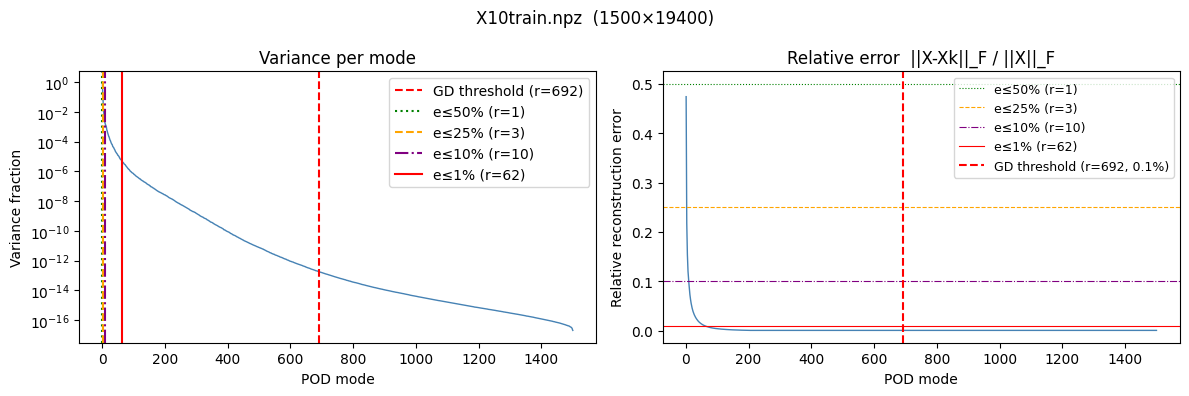

  re50=1,re25=3,re10=10,re1=62, GD rank=692 (0.1%)
Processing X11train.npz...
  Running SVD on shape (500, 19400)...


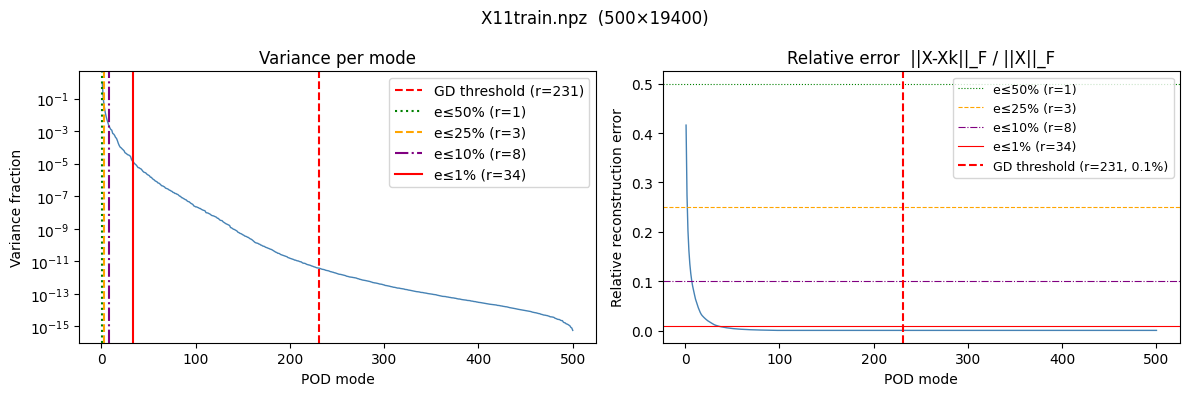

  re50=1,re25=3,re10=8,re1=34, GD rank=231 (0.1%)


In [4]:
results = []

for fname in TRAIN_FILES:
    print(f"Processing {fname}...")
    X = np.load(DATA_DIR / fname)["X"]
    X = X - X.mean(axis=0)  # mean-centre along time axis (standard for POD)

    print(f"  Running SVD on shape {X.shape}...")
    _, S, _ = np.linalg.svd(X, full_matrices=False)

    var_ratio = S**2 / (S**2).sum()
    cum_var = np.cumsum(var_ratio)
    rel_error = np.sqrt(1 - cum_var)

    threshold, n_gd = gavish_donoho_threshold(S, *X.shape)

    if METRIC == "relative_error":
        # Thresholds equivalent to 75/90/95/99% variance, expressed as error
        thresh_levels = [0.50, 0.25, 0.10, 0.01]
        rank_keys = ["re50", "re25", "re10", "re1"]
        ranks = [rank_for_error(rel_error, t) for t in thresh_levels]
        level_labels = [f"e\u2264{t:.0%}" for t in thresh_levels]
        y_data = rel_error
        y_label = "Relative reconstruction error"
        y_title = "Relative error  ||X-Xk||_F / ||X||_F"
        gd_metric = float(rel_error[n_gd - 1]) if n_gd > 0 else 0.0
    else:  # "variance"
        thresh_levels = [0.75, 0.90, 0.95, 0.99]
        rank_keys = ["r75", "r90", "r95", "r99"]
        ranks = [rank_for_variance(cum_var, t) for t in thresh_levels]
        level_labels = [f"{int(t * 100)}%" for t in thresh_levels]
        y_data = cum_var
        y_label = "Cumulative variance"
        y_title = "Cumulative variance"
        gd_metric = float(cum_var[n_gd - 1]) if n_gd > 0 else 0.0

    line_styles = [":", "--", "-.", "-"]
    colors = ["green", "orange", "purple", "red"]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"{fname}  ({X.shape[0]}\u00d7{X.shape[1]})")

    # Left: scree plot (log scale) — always shows variance fraction per mode
    ax = axes[0]
    ax.semilogy(np.arange(1, len(S) + 1), var_ratio, linewidth=1, color="steelblue")
    ax.axvline(n_gd, color="r", linestyle="--", label=f"GD threshold (r={n_gd})")
    for r, lbl, ls, color in zip(ranks, level_labels, line_styles, colors):
        ax.axvline(r, color=color, linestyle=ls, label=f"{lbl} (r={r})")
    ax.set_xlabel("POD mode")
    ax.set_ylabel("Variance fraction")
    ax.set_title("Variance per mode")
    ax.legend()

    # Right: cumulative variance or relative error depending on METRIC
    ax = axes[1]
    ax.plot(np.arange(1, len(S) + 1), y_data, linewidth=1, color="steelblue")
    for level, r, lbl, ls, color in zip(thresh_levels, ranks, level_labels, line_styles, colors):
        ax.axhline(level, color=color, linestyle=ls, linewidth=0.8, label=f"{lbl} (r={r})")
    ax.axvline(
        n_gd, color="r", linestyle="--",
        label=f"GD threshold (r={n_gd}, {gd_metric:.1%})",
    )
    ax.set_xlabel("POD mode")
    ax.set_ylabel(y_label)
    ax.set_title(y_title)
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

    rank_vals = dict(zip(rank_keys, ranks))
    print(f"  {chr(44).join(f'{k}={v}' for k, v in rank_vals.items())}, GD rank={n_gd} ({gd_metric:.1%})")
    results.append(
        dict(
            file=fname,
            shape=X.shape,
            rank_keys=rank_keys,
            **rank_vals,
            gd_rank=n_gd,
            metric_at_gd=round(gd_metric, 4),
        )
    )


## Summary table

In [5]:
rank_keys = results[0]["rank_keys"] if results else ["r75", "r90", "r95", "r99"]
col_label = "RelErr@GD" if METRIC == "relative_error" else "Var@GD"
header = f"{'File':<14} {'Shape':<16}" + "".join(f" {k:>6}" for k in rank_keys) + f" {'GD rank':>8} {col_label:>10}"
print(header)
print("-" * len(header))
for r in results:
    shape_str = f"{r['shape'][0]}\u00d7{r['shape'][1]}"
    rank_cols = "".join(f" {r[k]:>6}" for k in rank_keys)
    print(f"{r['file']:<14} {shape_str:<16}{rank_cols} {r['gd_rank']:>8} {r['metric_at_gd']:>10.1%}")

File           Shape              re50   re25   re10    re1  GD rank  RelErr@GD
-------------------------------------------------------------------------------
X1train.npz    2000×19400            2      3     12     96      919       0.1%
X2train.npz    2000×19400            2      3     12    115      238       0.7%
X3train.npz    2000×19400            2      3     13   1739      131       3.6%
X4train.npz    500×19400             1      3     10     39      230       0.0%
X5train.npz    500×19400             1      3     10    170       72       1.2%
X6train.npz    1500×19400            2      4     12     83      696       0.1%
X7train.npz    1500×19400            1      3     10     70      694       0.1%
X8train.npz    1500×19400            2      3     10     75      692       0.1%
X9train.npz    500×19400             2      5      9     38      230       0.0%
X10train.npz   1500×19400            1      3     10     62      692       0.1%
X11train.npz   500×19400             1  

## Frobenius norm verification

Verify that `1 - cum_var[k-1]` equals the actual squared relative Frobenius
reconstruction error $\|X - X_k\|_F^2 / \|X\|_F^2$, computed by explicitly forming
the rank-$k$ approximation $X_k = U_{:k} \, \mathrm{diag}(S_{:k}) \, V_{:k}^\top$.

Uses `X4train` (500×19400) for speed; the identity holds for any matrix.

In [6]:
fname_v = "X4train.npz"
print(f"Loading {fname_v} for Frobenius verification...")
X_v = np.load(DATA_DIR / fname_v)["X"]
X_v = X_v - X_v.mean(axis=0)

U_v, S_v, Vt_v = np.linalg.svd(X_v, full_matrices=False)

var_ratio_v = S_v**2 / (S_v**2).sum()
cum_var_v = np.cumsum(var_ratio_v)
norm_X_sq = float((S_v**2).sum())  # ||X||²_F = sum(σ²)

_, n_gd_v = gavish_donoho_threshold(S_v, *X_v.shape)
check_ranks = sorted({
    rank_for_variance(cum_var_v, 0.75),
    rank_for_variance(cum_var_v, 0.90),
    rank_for_variance(cum_var_v, 0.95),
    rank_for_variance(cum_var_v, 0.99),
    n_gd_v,
})

print(f"\n{'Rank':>6}  {'cum_var[k-1]':>14}  {'1 - cum_var':>13}  "
      f"{'||X-Xk||²/||X||²':>18}  {'|diff|':>10}")
print("-" * 68)
for k in check_ranks:
    X_k = (U_v[:, :k] * S_v[:k]) @ Vt_v[:k, :]  # rank-k approximation
    frob_err_sq = float(np.linalg.norm(X_v - X_k, "fro") ** 2 / norm_X_sq)
    from_cum_var = float(1.0 - cum_var_v[k - 1])
    print(f"{k:>6}  {cum_var_v[k-1]:>14.8f}  {from_cum_var:>13.8f}  "
          f"{frob_err_sq:>18.8f}  {abs(frob_err_sq - from_cum_var):>10.2e}")

del U_v, Vt_v, X_k  # free memory

Loading X4train.npz for Frobenius verification...



  Rank    cum_var[k-1]    1 - cum_var    ||X-Xk||²/||X||²      |diff|
--------------------------------------------------------------------
     1      0.78919184     0.21080816          0.21078517    2.30e-05
     2      0.91678077     0.08321923          0.08321273    6.50e-06
     4      0.96116710     0.03883290          0.03882996    2.94e-06
    10      0.99194264     0.00805736          0.00805672    6.33e-07
   230      1.00000000     0.00000000          0.00000000    1.53e-10


## POD reconstruction on test data (X1train → X1test, pair 1)

Demonstrates how to reuse training POD modes on the test set:

1. Compute POD from `X1train`, keep the `r99` modes and the **training mean**
2. Load `X1test`, subtract the **training mean**, project onto the `r99`-dimensional basis
3. Reconstruct back to full space and compare Frobenius error (training vs test)
4. Score the reconstruction with `ctf4science.eval_module.evaluate` (pair 1 metrics:
   `short_time` at k=20, `long_time` spectral at k=200)

The prediction passed to `evaluate` is the POD reconstruction of the test data —
it measures how much information the rank-`r99` training subspace retains on unseen data.

In [7]:
from ctf4science.eval_module import evaluate

TEST_DIR = Path("../data/msfr/test")

# ── Step 1: POD from X1train ──────────────────────────────────────────────────
print("Loading X1train and computing POD...")
X_train = np.load(DATA_DIR / "X1train.npz")["X"]
mu_train = X_train.mean(axis=0)           # training mean — must reuse on test data
X_train_c = X_train - mu_train

print(f"  Running SVD on shape {X_train_c.shape}...")
U_tr, S_tr, Vt_tr = np.linalg.svd(X_train_c, full_matrices=False)

var_ratio_tr = S_tr**2 / (S_tr**2).sum()
cum_var_tr = np.cumsum(var_ratio_tr)
r99_tr = rank_for_variance(cum_var_tr, 0.99)
print(f"  r99 = {r99_tr} modes ({cum_var_tr[r99_tr - 1]:.4%} of training variance)")

Vt_pod = Vt_tr[:r99_tr, :]               # spatial POD modes, shape (r99, 19400)
del U_tr, Vt_tr, X_train_c               # free ~360 MB

# ── Step 2: Project test data onto training POD basis ────────────────────────
print("\nLoading X1test and projecting onto training POD basis...")
X_test = np.load(TEST_DIR / "X1test.npz")["X"]   # shape (500, 19400)

X_test_c = X_test - mu_train              # subtract TRAINING mean (not test mean)
coeffs   = X_test_c @ Vt_pod.T           # temporal coefficients, shape (500, r99)
X_pred   = coeffs   @ Vt_pod + mu_train  # reconstruct to full space, shape (500, 19400)

# ── Step 3: Frobenius reconstruction error — training vs test ────────────────────
# cum_var tracks the SQUARED Frobenius norm, so r99 means 1% of the squared norm is
# unrepresented: ||X-Xk||_F^2 / ||Xc||_F^2 = 1 - cum_var ≈ 0.01.
# The unsquared ratio ||X-Xk||_F / ||Xc||_F = sqrt(0.01) ≈ 10%, not 1%.
train_frob_sq = float(1.0 - cum_var_tr[r99_tr - 1])          # from singular values (= squared error)
train_frob    = float(
    np.linalg.norm(X_train - ((X_train - mu_train) @ Vt_pod.T @ Vt_pod + mu_train), "fro")
    / np.linalg.norm(X_train - mu_train, "fro")
)
test_frob = float(
    np.linalg.norm(X_test - X_pred, "fro")
    / np.linalg.norm(X_test_c, "fro")
)
print(f"  Frobenius reconstruction error (r99={r99_tr}):")
print(f"    Training squared  (= 1 - cum_var):          {train_frob_sq:.4%}")
print(f"    Training unsquared (= sqrt of above):       {train_frob:.4%}  ≈ sqrt({train_frob_sq:.4f}) = {train_frob_sq**0.5:.4f}")
print(f"    Test unsquared:                             {test_frob:.4%}")

# ── Step 4: Score with the ctf4science eval module ───────────────────────────
print("\nEvaluating with ctf4science (msfr, pair 1)...")
scores = evaluate("msfr", 1, X_pred)
print(f"  short_time (k=20):              {scores['short_time']:.4f}")
print(f"  long_time  (spectral, k=200):   {scores['long_time']:.4f}")
print("  (100 = perfect, scores < 0 indicate worse than trivial)")

Loading X1train and computing POD...
  Running SVD on shape (2000, 19400)...
  r99 = 12 modes (99.0982% of training variance)

Loading X1test and projecting onto training POD basis...
  Frobenius reconstruction error (r99=12):
    Training squared  (= 1 - cum_var):          0.9018%
    Training unsquared (= sqrt of above):       9.4978%  ≈ sqrt(0.0090) = 0.0950
    Test unsquared:                             11.9358%

Evaluating with ctf4science (msfr, pair 1)...
  short_time (k=20):              87.2194
  long_time  (spectral, k=200):   98.3433
  (100 = perfect, scores < 0 indicate worse than trivial)
